# Tarea 3 - 2026
**Curso:** DAML 

**Fecha de entrega:** 29/06/2026

**Nombre:** Vicente Carrasco Pereira

---


**P1: Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.**

La base contiene 41.854 observaciones y 24 variables, que se ordenan en tres grupos según su naturaleza. Por un lado están las variables continuas, como la edad, el índice de masa corporal estandarizado (imce), la frecuencia de actividad física y los años de escolaridad de la madre y del padre. Por otro lado están las trece habilidades socioemocionales (sk1 a sk13), que son escalas tipo Likert de 1 a 5. Finalmente están las variables categóricas, como el sexo, el área de residencia, la presencia del padre y de la madre en el hogar, y la situación laboral de la madre. Distinguir estos grupos es importante porque cada uno admite un tratamiento estadístico distinto más adelante.

En cuanto a los datos faltantes, solo dos variables presentan ausencias: la actividad física, con un 3,4 por ciento de casos sin dato, y la escolaridad de la madre, con un 1,3 por ciento. Como la proporción es baja y ambas escalas son asimétricas, se imputan los valores faltantes usando la mediana, que es una medida robusta, y se conserva una variable indicadora que registra qué casos fueron imputados. Además, las variables de presencia del padre y de la madre traían un código 2 para indicar más de un progenitor en el hogar; como lo relevante es solo si el progenitor está presente o no, ese código se unifica con el valor 1 dejando la variable como binaria.

Respecto de la forma de las distribuciones, las habilidades socioemocionales se concentran en los valores bajos, ya que la mayoría de los niños obtiene puntajes favorables, lo que genera una asimetría hacia la derecha. Al revisar valores extremos aparece que cerca de un 8 por ciento de los casos tiene un imce muy alejado del promedio, pero se trata de puntajes z clínicamente válidos y la propia base ya viene acotada a un rango razonable de cinco desviaciones estándar. Por esa razón los valores extremos no se eliminan, ya que corresponden justamente a los casos de sobrepeso que interesa estudiar y no a errores de registro.

---

**P2: A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).**

Antes de estimar el modelo es necesario que todas las variables apunten en el mismo sentido lógico. Doce de las trece habilidades están codificadas de modo que un valor bajo es lo favorable, pero la agresividad (sk7) está al revés, por lo que un valor alto sería lo desfavorable. Para homogeneizar las escalas se invierte la codificación con la transformación 6-x, de manera que en todas las variables un valor más alto signifique siempre algo positivo. Una vez hecho esto, los indicadores de adecuación muestral son buenos: el índice KMO alcanza un valor de 0,87 y la prueba de esfericidad de Bartlett es claramente significativa, lo que confirma que las variables comparten suficiente información común como para justificar un modelo de factores.

Para decidir el número de factores se usan dos criterios que entregan el mismo resultado. Tanto la regla de Kaiser, que retiene los factores con autovalor mayor que uno, como el análisis paralelo de Horn coinciden en sugerir tres factores. Aplicando una rotación oblicua, que permite que los factores estén correlacionados entre sí, las variables se agrupan de forma muy clara. Un primer factor reúne a sk9, sk10, sk11, sk12 y sk13, todas asociadas a la curiosidad y el interés cognitivo. Un segundo factor agrupa a sk1, sk2, sk3 y sk4, ligadas al afecto y la expresión emocional. Un tercer factor reúne a sk5, sk6 y sk8, vinculadas al juego y la cooperación social. La única variable que no aporta información útil es la agresividad (sk7), cuya comunalidad es prácticamente cero, lo que indica que no comparte el mismo eje que las habilidades positivas. Por ese motivo se la deja fuera del modelo confirmatorio.

---
**P3: Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.**

A partir de la estructura encontrada se construye un modelo en el que cada variable carga en un solo factor, usando los doce indicadores informativos. Los tres factores reciben nombres según el concepto que comparten sus variables: Afecto, formado por sk1, sk2, sk3 y sk4; Social, formado por sk5, sk6 y sk8; y Cognitivo, formado por sk9, sk10, sk11, sk12 y sk13. El ajuste del modelo resulta aceptable y bueno, con índices de bondad de ajuste por encima del umbral habitual de 0,90 y un error de aproximación bajo, cercano a 0,05. La prueba de chi cuadrado sale significativa, pero esto se debe al tamaño enorme de la muestra, situación en la que esa prueba tiende a rechazar casi cualquier modelo, por lo que se le da más peso a los otros indicadores.

En cuanto a la importancia de cada medida, todas las variables presentan cargas estandarizadas razonables, en un rango que va aproximadamente de 0,52 a 0,74, de modo que ninguna resulta redundante dentro de su factor. Los tres factores están moderada y altamente correlacionados entre sí, con valores entre 0,60 y 0,66, lo que es coherente con la idea de que se trata de tres caras de un mismo desarrollo socioemocional y justifica haber usado una rotación oblicua. Finalmente, los puntajes factoriales predichos para cada niño se calculan y se guardan en el archivo predicciones_cfa.csv, quedando disponibles como variables predictoras para las preguntas siguientes.

---
**P4: Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).**

Siguiendo la indicación de simplificar el problema, se excluye a las desempleadas, que son la categoría minoritaria, y se arma un objetivo binario que distingue entre madres empleadas y madres dedicadas a labores domésticas. Con esta definición quedan 37.545 observaciones, y la clase mayoritaria representa alrededor de un 55 por ciento, valor que sirve como referencia mínima que cualquier modelo útil debería superar. Como predictores se usan exclusivamente los tres puntajes factoriales obtenidos en la pregunta anterior.

El procedimiento de evaluación, que se mantiene igual en las preguntas siguientes, consiste en separar los datos en entrenamiento y prueba respetando la proporción de las clases, optimizar los hiperparámetros mediante una búsqueda en grilla validada con cinco pliegues, y dar más peso a la métrica macro-F1 junto con un ajuste de clases balanceado para evitar que el modelo prediga siempre la categoría más frecuente. El Random Forest alcanza una exactitud de 0,52 y un macro-F1 de 0,51, valores muy cercanos a la referencia mínima. La conclusión es que con solo tres dimensiones socioemocionales del niño apenas se puede anticipar la situación laboral de la madre, algo esperable porque no existe una razón teórica fuerte que vincule ambos aspectos.

---
**P5: Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).**

Manteniendo el mismo objetivo y el mismo procedimiento, se agregan tres modelos adicionales: XGBoost, una máquina de soporte vectorial con kernel radial y un modelo de Stacking que combina a los tres modelos base con una regresión logística como integrador final. En cuanto al desempeño, los cuatro modelos quedan muy parecidos entre sí y todos cerca de la referencia mínima. El Stacking obtiene el mejor macro-F1, cercano a 0,51, aunque la diferencia con el resto es muy pequeña.

Donde sí aparecen diferencias importantes es en la eficiencia de cómputo. XGBoost es el más rápido de entrenar, ya que demora menos de un segundo. La máquina de soporte vectorial escala mal cuando crece el número de observaciones y tarda alrededor de veinticinco segundos. El Stacking es el más costoso de todos, con cerca de ciento setenta segundos, porque debe entrenar los tres modelos base más el integrador. Como todos rinden prácticamente igual, la elección más razonable sería XGBoost, que entrega el mismo resultado a una fracción del costo. La lectura general es que el verdadero límite está en la información disponible, que se reduce a tres puntajes, y no en el algoritmo elegido.

---
**P6: Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?**

Se aplica el método K-Means sobre las variables imce y actividad física, previamente estandarizadas para que ambas tengan el mismo peso en el cálculo de distancias. El número de grupos se elige con el coeficiente de silueta, que favorece una solución de tres grupos. El primero corresponde a niños con imce normal y actividad baja, el segundo a niños con imce alto y actividad también baja, que constituye un perfil de riesgo por combinar sobrepeso y sedentarismo, y el tercero a niños con actividad alta e imce intermedio.

El hallazgo más interesante es que el grupo de riesgo no reporta menos actividad física que el grupo de peso normal, ya que ambos presentan niveles muy parecidos. Esto sugiere que el imce elevado no se explica únicamente por la frecuencia de actividad declarada y que probablemente intervienen otros factores, como la alimentación o la calidad de la actividad, que estas dos variables por sí solas no logran capturar.

---
**P7: Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?**

El grupo con mayor imce promedio es el perfil de riesgo identificado antes, que reúne alrededor de quince mil observaciones. Al volver a estimar sobre este subgrupo el mejor modelo de la pregunta anterior, es decir el Stacking, el desempeño no mejora: la exactitud y el macro-F1 se mantienen en el mismo orden que en la muestra completa e incluso quedan al nivel de la referencia mínima del subgrupo. La conclusión es que la débil relación entre las habilidades socioemocionales del niño y el empleo de la madre es robusta y no era un efecto producido por mezclar grupos con distinto peso corporal. Trabajar con una muestra más homogénea no aporta información nueva.

---
**P8: Revise el notebook Sentiment_Analysis.ipynb. Considere la variable narrative en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables sk. Compare y discuta sus resultados.**

Siguiendo el flujo del notebook de referencia, se procesa la variable de texto narrativa mediante una función que la pasa a minúsculas, conserva solo letras, elimina las palabras vacías en español y luego la convierte en una representación de frecuencia de términos, sobre la cual se entrena una máquina de soporte vectorial lineal. La diferencia con la pregunta anterior es que aquí el modelo solo observa el texto, ya que se excluyen las variables sk. El resultado, con una exactitud y un macro-F1 cercanos a 0,52, queda en el mismo rango que el modelo de la Pregunta 5 y nuevamente próximo a la referencia mínima.

La interpretación es directa. Según el diccionario de datos, la narrativa es una paráfrasis generada de manera automática a partir de las trece habilidades socioemocionales. Por lo tanto, al excluir esas variables y quedarse solo con el texto, no se está incorporando información nueva sobre la situación laboral de la madre, sino una reescritura de la misma señal que ya había resultado poco predictiva. El valor del ejercicio es principalmente metodológico, porque permite implementar correctamente un flujo de procesamiento de lenguaje natural, y al mismo tiempo confirma el resultado central de las preguntas anteriores: el perfil socioemocional del niño, ya sea como puntajes o como texto, apenas se relaciona con que la madre trabaje o no.

# Librerias

In [1]:
import warnings, re, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import semopy

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, silhouette_score)
from xgboost import XGBClassifier

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

---
## 1. Carga, exploración y limpieza

In [2]:
df = pd.read_csv('../../../data/junaeb2n.csv')
print('Dimensiones:', df.shape)
df.head()

items_sk = [f"sk{k}" for k in range(1, 14)]

Dimensiones: (41854, 24)


In [3]:
tipos = (df.dtypes.astype(str).value_counts()
         .rename_axis("dtype").reset_index(name="n_columnas"))
print(tipos.to_string(index=False), "\n")
print("Continuas :", ["edad", "imce", "act_fisica", "educm", "educp"])
print("Categóricas:", ["sexo", "area", "vive_padre", "vive_madre", "madre_work"])

  dtype  n_columnas
  int64          20
float64           3
    str           1 

Continuas : ['edad', 'imce', 'act_fisica', 'educm', 'educp']
Categóricas: ['sexo', 'area', 'vive_padre', 'vive_madre', 'madre_work']


In [4]:
faltan = df.isna().sum()
faltan = faltan[faltan > 0].sort_values(ascending=False)
pd.DataFrame({"n_faltantes": faltan,
             "pct": (100 * faltan / len(df)).round(2)})

,n_faltantes,pct
act_fisica,1435,3.43
educm,551,1.32


In [5]:
df[["edad", "imce", "act_fisica", "educm", "educp"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
edad,41854.0,83.07,3.99,62.00,81.0,82.00,84.00,107.00
imce,41854.0,1.01,1.38,-5.02,0.1,0.97,1.93,5.04
act_fisica,40419.0,2.55,1.07,1.00,2.0,2.00,3.00,5.00
educm,41303.0,12.98,3.37,0.00,11.0,13.00,15.00,22.00
educp,41854.0,12.90,3.46,0.00,11.0,13.00,14.00,22.00


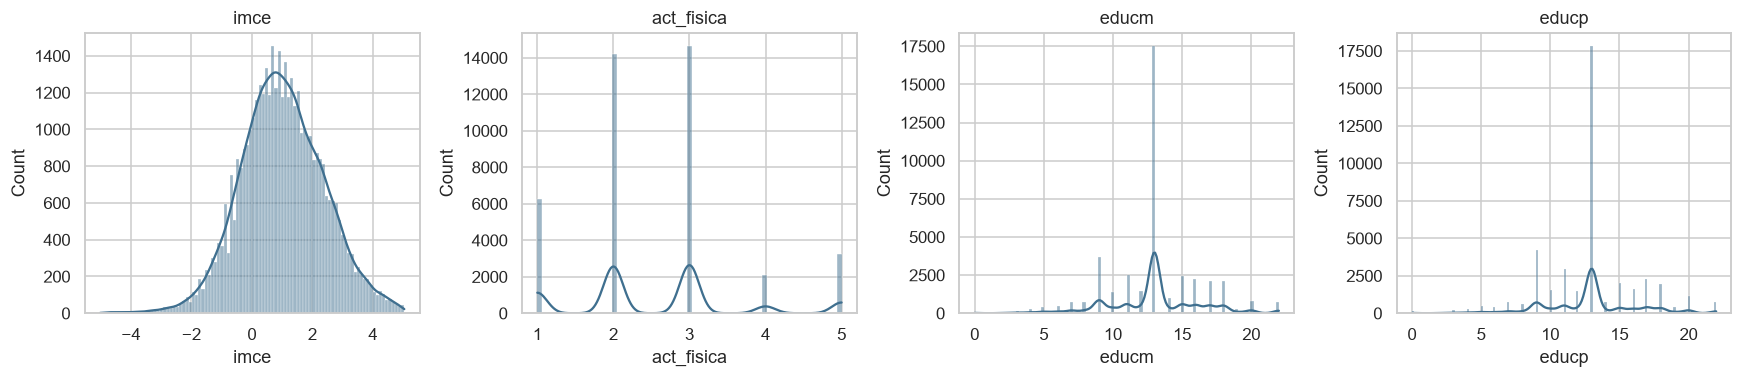

Outliers (regla IQR 1.5x):
  imce        fuera de [  -2.64,    4.67]:   426 ( 1.0%)
  act_fisica  fuera de [   0.50,    4.50]:  3263 ( 7.8%)
  educm       fuera de [   5.00,   21.00]:  1321 ( 3.2%)
  educp       fuera de [   6.50,   18.50]:  3878 ( 9.3%)

IMCE con |z|>3: 3356 (8.02%). Son puntajes-z clínicamente válidos (la base ya viene acotada a ±5 DE), se conservan.


In [6]:
continuas = ["imce", "act_fisica", "educm", "educp"]
fig, ejes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, col in zip(ejes, continuas):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#3f6f8f")
    ax.set_title(col)
plt.tight_layout(); plt.show()

print("Outliers (regla IQR 1.5x):")
for col in continuas:
    q1, q3 = df[col].quantile([.25, .75])
    rango = q3 - q1
    bajo, alto = q1 - 1.5 * rango, q3 + 1.5 * rango
    n = int(((df[col] < bajo) | (df[col] > alto)).sum())
    print(f"  {col:11s} fuera de [{bajo:7.2f}, {alto:7.2f}]: {n:5d} ({100*n/len(df):4.1f}%)")

extr = int((df["imce"].abs() > 3).sum())
print(f"\nIMCE con |z|>3: {extr} ({100*extr/len(df):.2f}%). Son puntajes-z clínicamente "
      "válidos (la base ya viene acotada a ±5 DE), se conservan.")

Solo `act_fisica` (~3.4 %) y `educm` (~1.3 %) tienen datos
faltantes. Se imputan por mediana (robusta a la asimetría de estas escalas) y se guarda una
indicadora `*_imputado` para no perder la señal de que el valor fue imputado. Los códigos `2` de
`vive_padre`/`vive_madre` ("más de un progenitor") se colapsan a *presencia en el hogar* = 1. No se
eliminan outliers: corresponden a casos plausibles y `imce` ya está acotado por construcción.

In [7]:
df_lim = df.copy()

for col in ["act_fisica", "educm"]:
    df_lim[f"{col}_imputado"] = df_lim[col].isna().astype(int)
    df_lim[col] = df_lim[col].fillna(df_lim[col].median())

for col in ["vive_padre", "vive_madre"]:
    df_lim[col] = (df_lim[col] >= 1).astype(int)

print("Faltantes restantes en sk + continuas:",
      int(df_lim[items_sk + continuas].isna().sum().sum()))
print("vive_padre:", sorted(df_lim["vive_padre"].unique()),
      "| vive_madre:", sorted(df_lim["vive_madre"].unique()))

Faltantes restantes en sk + continuas: 0
vive_padre: [np.int64(0), np.int64(1)] | vive_madre: [np.int64(0), np.int64(1)]


---
## 2. Análisis Factorial Exploratorio (EFA)

In [8]:
# Reorientación a "mayor = más favorable" para las 13 (incluido sk7).
sk_pos = 6 - df_lim[items_sk]

# Chequeo: si la orientación es homogénea, sk7 debe correlacionar (débil pero) positivamente.
corr_sk7 = sk_pos.corr()["sk7"].drop("sk7")
print("Correlación de sk7 (reorientado) con el resto de ítems:")
print(corr_sk7.round(3).to_string())
ok = (corr_sk7 > 0).all()
print(f"\nMín={corr_sk7.min():.3f}  Máx={corr_sk7.max():.3f}  ->  "
      f"{'todas positivas: orientación correcta' if ok else 'revisar orientación'}")

Correlación de sk7 (reorientado) con el resto de ítems:
sk1     0.121
sk2     0.124
sk3     0.041
sk4     0.072
sk5     0.084
sk6     0.187
sk8     0.064
sk9     0.082
sk10    0.088
sk11    0.106
sk12    0.038
sk13    0.055

Mín=0.038  Máx=0.187  ->  todas positivas: orientación correcta


### 2.A  Adecuación muestral (KMO y Bartlett)

In [9]:
_, kmo_global = calculate_kmo(sk_pos)
chi2_b, p_b = calculate_bartlett_sphericity(sk_pos)
print(f"KMO global = {kmo_global:.3f}  (>0.8 = 'meritorio')")
print(f"Bartlett: chi2 = {chi2_b:,.1f}  |  p = {p_b:.2e}")

KMO global = 0.873  (>0.8 = 'meritorio')
Bartlett: chi2 = 122,116.7  |  p = 0.00e+00


### 2.B  Número de factores

Autovalores reales: [4.154 1.337 1.099 0.999 0.772 0.701 0.692 0.684 0.597 0.516 0.506 0.487
 0.456]
Factores por Kaiser (>1):        3
Factores por análisis paralelo:  3


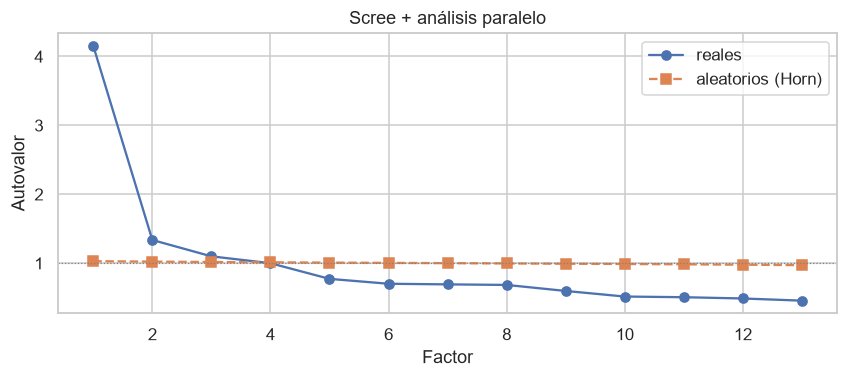


Se adopta una solución de 3 factores.


In [10]:
fa_ini = FactorAnalyzer(n_factors=len(items_sk), rotation=None, method="ml")
fa_ini.fit(sk_pos)
autoval, _ = fa_ini.get_eigenvalues()

# Análisis paralelo: autovalores esperados bajo datos puramente aleatorios.
n_obs, n_var = sk_pos.shape
rng = np.random.default_rng(SEED)
sim = np.empty((100, n_var))
for i in range(100):
    fa_r = FactorAnalyzer(n_factors=n_var, rotation=None, method="principal")
    fa_r.fit(rng.standard_normal((n_obs, n_var)))
    sim[i] = fa_r.get_eigenvalues()[0]
umbral = sim.mean(axis=0)

k_kaiser  = int((autoval > 1).sum())
k_horn    = int((autoval > umbral).sum())
print("Autovalores reales:", np.round(autoval, 3))
print(f"Factores por Kaiser (>1):        {k_kaiser}")
print(f"Factores por análisis paralelo:  {k_horn}")

plt.figure(figsize=(8, 3.6))
plt.plot(range(1, n_var + 1), autoval, "o-", label="reales")
plt.plot(range(1, n_var + 1), umbral, "s--", label="aleatorios (Horn)")
plt.axhline(1, color="grey", lw=.8, ls=":")
plt.xlabel("Factor"); plt.ylabel("Autovalor"); plt.title("Scree + análisis paralelo")
plt.legend(); plt.tight_layout(); plt.show()

N_FACTORES = k_horn  # criterios coincidentes
print(f"\nSe adopta una solución de {N_FACTORES} factores.")

### 2.C  Cargas rotadas (oblimin) y variable no informativa

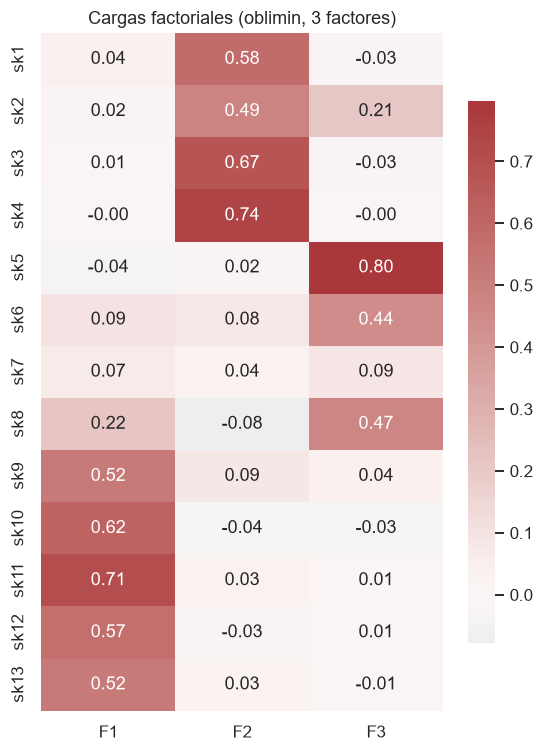

         F1     F2     F3  comunalidad
sk1   0.043  0.584 -0.026        0.343
sk2   0.022  0.486  0.206        0.279
sk3   0.010  0.675 -0.026        0.456
sk4  -0.005  0.743 -0.001        0.552
sk5  -0.038  0.024  0.798        0.638
sk6   0.094  0.080  0.445        0.213
sk7   0.067  0.037  0.090        0.014
sk8   0.219 -0.078  0.469        0.273
sk9   0.519  0.087  0.043        0.278
sk10  0.619 -0.035 -0.030        0.386
sk11  0.706  0.033  0.009        0.500
sk12  0.570 -0.029  0.008        0.326
sk13  0.520  0.025 -0.008        0.271


In [11]:
fa = FactorAnalyzer(n_factors=N_FACTORES, rotation="oblimin", method="ml")
fa.fit(sk_pos)
cargas = pd.DataFrame(fa.loadings_, index=items_sk,
                      columns=[f"F{i+1}" for i in range(N_FACTORES)])
comun = pd.Series(fa.get_communalities(), index=items_sk, name="comunalidad")

plt.figure(figsize=(5.2, 7))
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="vlag", center=0, cbar_kws={"shrink": .8})
plt.title(f"Cargas factoriales (oblimin, {N_FACTORES} factores)")
plt.tight_layout(); plt.show()

print(pd.concat([cargas, comun], axis=1).round(3).to_string())

In [12]:
print("Asignación por carga dominante (|carga| > 0.4):")
for f in cargas.columns:
    print(f"  {f}: {cargas.index[cargas[f].abs() > 0.4].tolist()}")

menos_info = comun.idxmin()
print(f"\nVariable menos informativa: {menos_info} (comunalidad = {comun.min():.3f}).")
print("La agresividad no comparte varianza común con las habilidades adaptativas; se excluye del CFA.")

Asignación por carga dominante (|carga| > 0.4):
  F1: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
  F2: ['sk1', 'sk2', 'sk3', 'sk4']
  F3: ['sk5', 'sk6', 'sk8']

Variable menos informativa: sk7 (comunalidad = 0.014).
La agresividad no comparte varianza común con las habilidades adaptativas; se excluye del CFA.


Los 13 ítems se resumen en 3 factores (Kaiser y análisis paralelo coinciden;
KMO ≈ 0.87, Bartlett p ≈ 0). Las cargas dominantes agrupan: `sk9`–`sk13` (interés
cognitivo-exploratorio), `sk1`–`sk4` (expresión afectiva) y `sk5`,`sk6`,`sk8` (juego/cooperación
social). `sk7` (agresividad) tiene comunalidad casi nula: no es informativa para la estructura
común y se trata como dimensión aparte.

---
## 3. Análisis Factorial Confirmatorio (CFA)

Estructura simple (cada ítem carga en un solo factor) sobre los 12 ítems informativos,
excluyendo `sk7`. Nombres propuestos según el concepto común:

- **Afecto** =~ `sk1 + sk2 + sk3 + sk4`
- **Social** =~ `sk5 + sk6 + sk8`
- **Cognitivo** =~ `sk9 + sk10 + sk11 + sk12 + sk13`

In [13]:
modelo_cfa = """
Afecto    =~ sk1 + sk2 + sk3 + sk4
Social    =~ sk5 + sk6 + sk8
Cognitivo =~ sk9 + sk10 + sk11 + sk12 + sk13
"""
cfa = semopy.Model(modelo_cfa)
cfa.fit(sk_pos)
ajuste = semopy.calc_stats(cfa)
print("Índices de ajuste:")
print(ajuste[["chi2", "DoF", "CFI", "TLI", "RMSEA"]].round(3).to_string(index=False))

Índices de ajuste:
    chi2  DoF   CFI   TLI  RMSEA
6148.096   51 0.949 0.934  0.053


### 3.A  Importancia de cada medida (cargas estandarizadas)

In [14]:
factores = ["Afecto", "Social", "Cognitivo"]
tabla = cfa.inspect(std_est=True)

cargas_cfa = tabla[(tabla["op"] == "~") & (tabla["rval"].isin(factores))][["rval", "lval", "Est. Std"]].copy()
cargas_cfa.columns = ["factor", "item", "carga_std"]
cargas_cfa["carga_std"] = cargas_cfa["carga_std"].astype(float).round(3)
print(cargas_cfa.sort_values(["factor", "carga_std"], ascending=[True, False]).to_string(index=False))

   factor item  carga_std
   Afecto  sk4      0.715
   Afecto  sk2      0.652
   Afecto  sk3      0.646
   Afecto  sk1      0.600
Cognitivo sk11      0.736
Cognitivo  sk9      0.608
Cognitivo sk10      0.565
Cognitivo sk12      0.551
Cognitivo sk13      0.523
   Social  sk5      0.723
   Social  sk6      0.572
   Social  sk8      0.559


### 3.B  Correlación entre factores

In [15]:
corr_fac = tabla[(tabla["op"] == "~~") & (tabla["lval"] != tabla["rval"])].copy()
corr_fac = corr_fac[corr_fac["lval"].isin(factores) & corr_fac["rval"].isin(factores)]
corr_fac = corr_fac[["lval", "rval", "Est. Std"]]
corr_fac.columns = ["factor_a", "factor_b", "correlacion"]
print(corr_fac.round(3).to_string(index=False))

 factor_a factor_b  correlacion
Cognitivo   Afecto        0.612
Cognitivo   Social        0.596
   Social   Afecto        0.658


### 3.C  Predicciones (factor scores)

In [16]:
puntajes = cfa.predict_factors(sk_pos)[factores]
puntajes.columns = factores
puntajes.to_csv("predicciones_cfa.csv", index=False)
df_lim = pd.concat([df_lim.reset_index(drop=True), puntajes.reset_index(drop=True)], axis=1)
print("Predicciones guardadas en 'predicciones_cfa.csv'.")
print(puntajes.describe().round(3).to_string())

Predicciones guardadas en 'predicciones_cfa.csv'.
          Afecto     Social  Cognitivo
count  41854.000  41854.000  41854.000
mean      -0.000      0.000     -0.000
std        0.214      0.356      0.367
min       -2.020     -3.001     -2.767
25%       -0.066     -0.151     -0.179
50%        0.084      0.126      0.112
75%        0.145      0.269      0.275
max        0.160      0.308      0.353


El modelo de 3 factores con estructura simple ajusta de forma aceptable-buena
(CFI/TLI > 0.90, RMSEA < 0.06; el $\chi^2$ es significativo por el N > 40.000, donde el test es muy
sensible). Las cargas estandarizadas son razonables en todos los ítems y los factores están
moderada-altamente correlacionados, coherente con que son facetas de un mismo constructo
socioemocional. Los *scores* se guardan y se usan como *features* desde la P4.

---
## 4. Random Forest target `madre_work` (binario)

Se excluye la categoría minoritaria `0` (desempleada) y se construye el target binario
`1 = empleada` vs `0 = labor doméstica`. *Features*: los 3 *factor scores* de la P3.

Protocolo (consistente en P4-P7): partición *train/test* 80/20 estratificada; búsqueda de
hiperparámetros con `GridSearchCV` + `StratifiedKFold(5)` sobre una submuestra del *train*
(controla el costo, sobre todo del SVM); evaluación final sobre el *test* reservado. Se usa
`macro-F1` (apropiado para clases desbalanceadas) y `class_weight="balanced"` para evitar que los
modelos colapsen a la clase mayoritaria.

In [17]:
caracteristicas = ["Afecto", "Social", "Cognitivo"]

sub = df_lim[df_lim["madre_work"] != 0].copy()
sub["target"] = (sub["madre_work"] == 1).astype(int)      # 1=empleada, 0=labor doméstica

X = sub[caracteristicas].to_numpy()
y = sub["target"].to_numpy()
print("Obs. tras excluir desempleadas:", len(y))
print("Distribución:", {"labor_dom (0)": int((y == 0).sum()), "empleada (1)": int((y == 1).sum())})
print(f"Baseline (clase mayoritaria): {np.bincount(y).max() / len(y):.4f}")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

n_tune = min(6000, len(X_tr))
idx = np.random.RandomState(SEED).choice(len(X_tr), n_tune, replace=False)
X_tune, y_tune = X_tr[idx], y_tr[idx]
print(f"Submuestra de tuning: {n_tune}")

Obs. tras excluir desempleadas: 37545
Distribución: {'labor_dom (0)': 17026, 'empleada (1)': 20519}
Baseline (clase mayoritaria): 0.5465
Submuestra de tuning: 6000


In [18]:
def evaluar(nombre, estimador, Xtr, ytr, Xte, yte):
    """Entrena, predice y devuelve métricas + tiempos."""
    t0 = time.perf_counter(); estimador.fit(Xtr, ytr); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = estimador.predict(Xte); t_pred = time.perf_counter() - t0
    return {"modelo": nombre,
            "accuracy": accuracy_score(yte, pred),
            "macro_F1": f1_score(yte, pred, average="macro"),
            "t_fit_s": t_fit, "t_pred_s": t_pred, "_pred": pred}

def confusion(yte, pred, titulo):
    cm = confusion_matrix(yte, pred)
    print(f"\n{titulo}")
    print(pd.DataFrame(cm, index=["real:dom", "real:emp"],
                       columns=["pred:dom", "pred:emp"]).to_string())

In [19]:
rejilla_rf = {"n_estimators": [200, 400],
              "max_depth": [None, 8, 14],
              "min_samples_leaf": [1, 10, 30]}
busq_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    rejilla_rf, cv=kfold, scoring="f1_macro", n_jobs=-1)
t0 = time.perf_counter(); busq_rf.fit(X_tune, y_tune); t_tune_rf = time.perf_counter() - t0
print("Mejores hiperparámetros RF:", busq_rf.best_params_)
print(f"macro-F1 (CV tuning): {busq_rf.best_score_:.4f}  |  tuning {t_tune_rf:.1f}s")

rf = RandomForestClassifier(**busq_rf.best_params_, class_weight="balanced",
                            random_state=SEED, n_jobs=-1)
res_rf = evaluar("RandomForest", rf, X_tr, y_tr, X_te, y_te)
print(f"\nTest -> accuracy={res_rf['accuracy']:.4f}  macro-F1={res_rf['macro_F1']:.4f}")
confusion(y_te, res_rf["_pred"], "Matriz de confusión — Random Forest")
print(classification_report(y_te, res_rf["_pred"], target_names=["labor_dom", "empleada"]))

Mejores hiperparámetros RF: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}
macro-F1 (CV tuning): 0.5142  |  tuning 43.2s

Test -> accuracy=0.5202  macro-F1=0.5063

Matriz de confusión — Random Forest
          pred:dom  pred:emp
real:dom      1323      2082
real:emp      1521      2583
              precision    recall  f1-score   support

   labor_dom       0.47      0.39      0.42      3405
    empleada       0.55      0.63      0.59      4104

    accuracy                           0.52      7509
   macro avg       0.51      0.51      0.51      7509
weighted avg       0.51      0.52      0.51      7509



Con solo 3 dimensiones socioemocionales del niño/a, el desempeño queda
cercano al *baseline*: no hay una razón teórica fuerte para que el perfil socioemocional infantil
prediga la situación laboral de la madre. El uso de `macro-F1` + `balanced` evita el espejismo de un
*accuracy* alto logrado prediciendo siempre la clase mayoritaria.

---
## 5. XGBoost vs SVM vs Stacking

Mismo target y protocolo. Se comparan desempeño (*accuracy*, `macro-F1`) y eficiencia
(tiempos de tuning, entrenamiento y predicción).

In [20]:
rejilla_xgb = {"n_estimators": [200, 400], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1]}
busq_xgb = GridSearchCV(
    XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=SEED, verbosity=0),
    rejilla_xgb, cv=kfold, scoring="f1_macro", n_jobs=-1)
t0 = time.perf_counter(); busq_xgb.fit(X_tune, y_tune); t_tune_xgb = time.perf_counter() - t0
xgb = busq_xgb.best_estimator_
print("Mejores XGBoost:", busq_xgb.best_params_, f"| tuning {t_tune_xgb:.1f}s")

Mejores XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400} | tuning 5.5s


In [21]:
rejilla_svm = {"svc__C": [0.5, 1, 10], "svc__gamma": ["scale", 0.1]}
pipe_svm = Pipeline([("escala", StandardScaler()),
                     ("svc", SVC(kernel="rbf", class_weight="balanced", cache_size=800))])
busq_svm = GridSearchCV(pipe_svm, rejilla_svm, cv=kfold, scoring="f1_macro", n_jobs=-1)
t0 = time.perf_counter(); busq_svm.fit(X_tune, y_tune); t_tune_svm = time.perf_counter() - t0
svm = busq_svm.best_estimator_
print("Mejores SVM:", busq_svm.best_params_, f"| tuning {t_tune_svm:.1f}s")

Mejores SVM: {'svc__C': 1, 'svc__gamma': 0.1} | tuning 10.5s


In [22]:
stacking = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("svm", svm)],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=kfold, n_jobs=-1)

In [23]:
filas = [evaluar("RandomForest", rf, X_tr, y_tr, X_te, y_te),
         evaluar("XGBoost",      xgb, X_tr, y_tr, X_te, y_te),
         evaluar("SVM (RBF)",    svm, X_tr, y_tr, X_te, y_te),
         evaluar("Stacking",     stacking, X_tr, y_tr, X_te, y_te)]

comparacion = pd.DataFrame(filas).drop(columns="_pred").set_index("modelo")
print(comparacion.round(4).to_string())

for r in filas:
    confusion(y_te, r["_pred"], f"Matriz de confusión - {r['modelo']}")

mejor_p5 = comparacion["macro_F1"].idxmax()
print(f"\nMejor modelo de la P5 (por macro-F1): {mejor_p5}")

              accuracy  macro_F1   t_fit_s  t_pred_s
modelo                                              
RandomForest    0.5202    0.5063    1.6743    0.1110
XGBoost         0.5340    0.4804    1.1337    0.0174
SVM (RBF)       0.5402    0.4993   28.5845   11.3937
Stacking        0.5276    0.5126  118.3936   11.2820

Matriz de confusión - RandomForest
          pred:dom  pred:emp
real:dom      1323      2082
real:emp      1521      2583

Matriz de confusión - XGBoost
          pred:dom  pred:emp
real:dom       799      2606
real:emp       893      3211

Matriz de confusión - SVM (RBF)
          pred:dom  pred:emp
real:dom       956      2449
real:emp      1004      3100

Matriz de confusión - Stacking
          pred:dom  pred:emp
real:dom      1321      2084
real:emp      1463      2641

Mejor modelo de la P5 (por macro-F1): Stacking


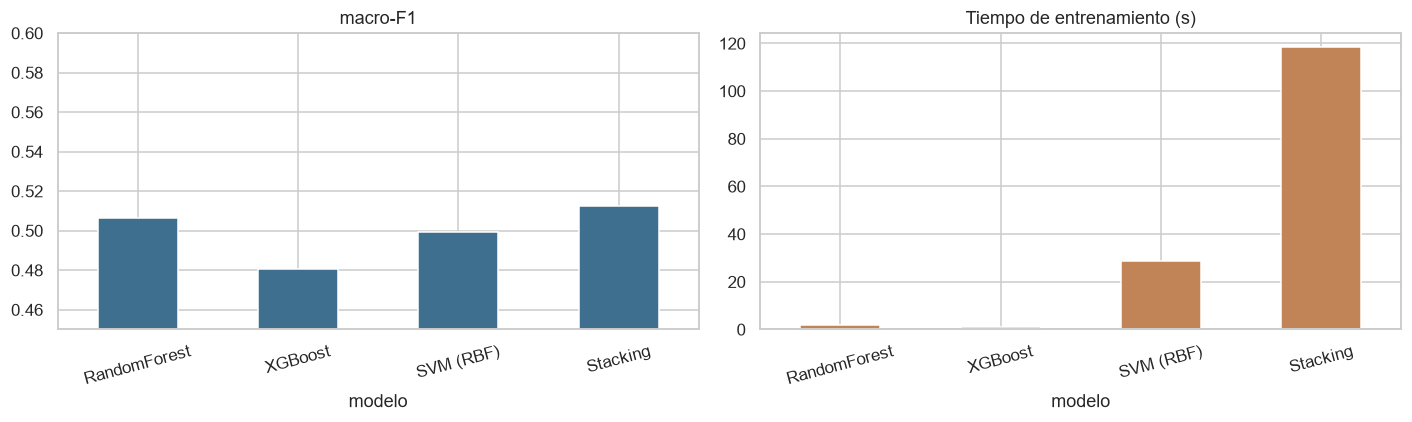

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
comparacion["macro_F1"].plot.bar(ax=ax[0], color="#3f6f8f"); ax[0].set_title("macro-F1")
ax[0].set_ylim(0.45, max(0.6, comparacion["macro_F1"].max() + 0.03))
comparacion["t_fit_s"].plot.bar(ax=ax[1], color="#c08457"); ax[1].set_title("Tiempo de entrenamiento (s)")
for a in ax: a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

Los cuatro modelos quedan muy próximos entre sí y cerca del *baseline*: el
cuello de botella es la información disponible (3 *scores*), no el algoritmo. En eficiencia,
XGBoost es el más rápido; el SVM-RBF escala mal con el número de observaciones (≈ O(n²)) y el
Stacking es el más costoso porque entrena los tres modelos base más el meta-modelo. La elección
racional sería XGBoost: igual desempeño a una fracción del costo.

---
## 6. Clustering (`imce` × `act_fisica`)

K-Means sobre las dos variables estandarizadas; el número de grupos se elige por el coeficiente de
**silueta**.

In [25]:
datos_clu = StandardScaler().fit_transform(df_lim[["imce", "act_fisica"]])

print("Silueta por número de clusters:")
for k in range(2, 6):
    etiquetas = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(datos_clu)
    s = silhouette_score(datos_clu, etiquetas, sample_size=8000, random_state=SEED)
    print(f"  k={k}: {s:.3f}")

Silueta por número de clusters:
  k=2: 0.342
  k=3: 0.381
  k=4: 0.382
  k=5: 0.370


        imce  act_fisica      n
grupo                          
0      0.003       2.232  19595
1      2.217       2.239  17026
2      0.886       4.624   5233


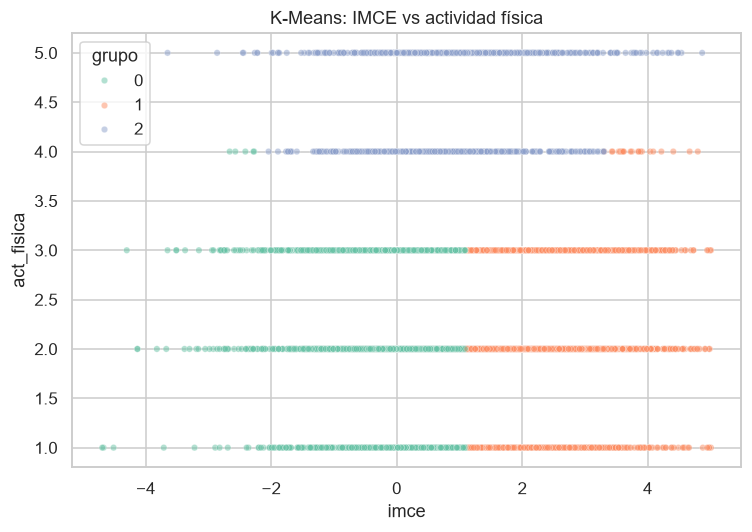

In [26]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(datos_clu)
df_lim["grupo"] = km.labels_

perfil = df_lim.groupby("grupo")[["imce", "act_fisica"]].mean()
perfil["n"] = df_lim["grupo"].value_counts().sort_index()
print(perfil.round(3).to_string())

muestra = df_lim.sample(min(8000, len(df_lim)), random_state=SEED)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=muestra, x="imce", y="act_fisica", hue="grupo",
                palette="Set2", s=18, alpha=0.5)
plt.title("K-Means: IMCE vs actividad física"); plt.tight_layout(); plt.show()

Con `k = 3` (silueta máxima y solución parsimoniosa) los grupos se separan
principalmente por IMCE, mientras la actividad física aísla al grupo activo: un grupo de IMCE
normal con actividad baja, un grupo de IMCE alto con actividad baja (perfil de riesgo:
sobrepeso + sedentarismo) y un grupo de actividad alta con IMCE intermedio. El grupo de riesgo no se
distingue por hacer menos actividad que el grupo normal, lo que sugiere que el IMCE elevado no se
explica solo por la frecuencia de actividad reportada.

---
## 7. Mejor modelo de la P5 sobre el grupo de mayor IMCE


In [27]:
grupo_imce = perfil["imce"].idxmax()
print(f"Grupo con mayor IMCE promedio: {grupo_imce} (IMCE medio = {perfil.loc[grupo_imce,'imce']:.3f})")

mascara = (df_lim["grupo"] == grupo_imce) & (df_lim["madre_work"] != 0)
sub7 = df_lim[mascara].copy()
sub7["target"] = (sub7["madre_work"] == 1).astype(int)
X7 = sub7[caracteristicas].to_numpy()
y7 = sub7["target"].to_numpy()
print("Subgrupo:", len(y7), "| distribución:",
      dict(zip(*np.unique(y7, return_counts=True))))

# Reconstruye el mejor modelo de la P5 con sus mejores hiperparámetros.
params_svm = {k.replace("svc__", ""): v for k, v in busq_svm.best_params_.items()}
constructores = {
    "RandomForest": lambda: RandomForestClassifier(**busq_rf.best_params_, class_weight="balanced",
                                                    random_state=SEED, n_jobs=-1),
    "XGBoost":      lambda: XGBClassifier(**busq_xgb.best_params_, tree_method="hist",
                                          eval_metric="logloss", random_state=SEED, verbosity=0),
    "SVM (RBF)":    lambda: Pipeline([("escala", StandardScaler()),
                                      ("svc", SVC(**params_svm, kernel="rbf",
                                                  class_weight="balanced"))]),
    "Stacking":     lambda: stacking,
}
modelo7 = constructores[mejor_p5]()

X7tr, X7te, y7tr, y7te = train_test_split(X7, y7, test_size=0.2, stratify=y7, random_state=SEED)
res7 = evaluar(mejor_p5, modelo7, X7tr, y7tr, X7te, y7te)
print(f"\n{mejor_p5} en subgrupo de mayor IMCE:")
print(f"  accuracy = {res7['accuracy']:.4f}  macro-F1 = {res7['macro_F1']:.4f}")
print(f"  baseline subgrupo = {np.bincount(y7te).max()/len(y7te):.4f}")
confusion(y7te, res7["_pred"], "Matriz de confusión - subgrupo de mayor IMCE")

Grupo con mayor IMCE promedio: 1 (IMCE medio = 2.217)
Subgrupo: 15225 | distribución: {np.int64(0): np.int64(6725), np.int64(1): np.int64(8500)}

Stacking en subgrupo de mayor IMCE:
  accuracy = 0.5475  macro-F1 = 0.5125
  baseline subgrupo = 0.5583

Matriz de confusión - subgrupo de mayor IMCE
          pred:dom  pred:emp
real:dom       426       919
real:emp       459      1241


Restringir al subgrupo de mayor IMCE (muestra más homogénea en peso) no
mejora la predicción de `madre_work`: el desempeño se mantiene en el mismo orden que en la muestra
completa. La débil asociación entre habilidades socioemocionales y empleo materno es robusta y
no un artefacto de mezclar subpoblaciones con distinto IMC.

---
## 8. Clasificación de texto (SVC) contraste con la P5

Se replica el flujo de `Sentiment_Analysis.ipynb`: una función de tokenización (minúsculas ->
solo letras -> quitar *stopwords* en español) + vectorización *bag-of-words* + un SVC lineal.
Mismo target binario, pero excluyendo las variables `sk`: el modelo solo "ve" el texto. Se usa
`class_weight="balanced"` para obtener un clasificador no degenerado.

In [28]:
stops_es = set(stopwords.words("spanish"))

COL_TEXTO = "narrative" if "narrative" in df.columns else "resumen_sk"

def normalizar(texto):
    """Tokenización estilo Sentiment_Analysis.ipynb: minúsculas, solo letras, sin stopwords."""
    limpio = re.sub(r"[^a-záéíóúüñ]+", " ", str(texto).lower())
    palabras = [w for w in limpio.split() if w not in stops_es and len(w) > 2]
    return " ".join(palabras)

texto_df = sub.copy()                      # mismas obs. del problema binario (sin desempleadas)
texto_df["texto"] = texto_df[COL_TEXTO].apply(normalizar)
y_txt = texto_df["target"].to_numpy()

print("Original  :", str(df_lim[COL_TEXTO].iloc[0])[:130])
print("Tokenizado:", texto_df["texto"].iloc[0][:130])

Original  : Las habilidades socioemocionales estan bien establecidas, con lo afectivo-emocional como area mas fuerte y la curiosidad e interes
Tokenizado: habilidades socioemocionales estan bien establecidas afectivo emocional area mas fuerte curiosidad intereses cognitivos mas rezaga


In [29]:
x_tr, x_te, yt_tr, yt_te = train_test_split(
    texto_df["texto"], y_txt, test_size=0.2, stratify=y_txt, random_state=SEED)

vect = CountVectorizer(ngram_range=(1, 2), min_df=5, max_features=400)
M_tr = vect.fit_transform(x_tr)
M_te = vect.transform(x_te)
print(f"Vocabulario: {len(vect.get_feature_names_out())} términos | matriz train {M_tr.shape}")

clf_txt = LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000)
t0 = time.perf_counter(); clf_txt.fit(M_tr, yt_tr); t_fit_txt = time.perf_counter() - t0
pred_txt = clf_txt.predict(M_te)

print(f"\nSVC lineal (texto) -> accuracy={accuracy_score(yt_te, pred_txt):.4f}  "
      f"macro-F1={f1_score(yt_te, pred_txt, average='macro'):.4f}  (fit {t_fit_txt:.1f}s)")
confusion(yt_te, pred_txt, "Matriz de confusión - SVC sobre texto")
print(classification_report(yt_te, pred_txt, target_names=["labor_dom", "empleada"]))

Vocabulario: 400 términos | matriz train (30036, 400)

SVC lineal (texto) -> accuracy=0.5194  macro-F1=0.5180  (fit 4.4s)

Matriz de confusión - SVC sobre texto
          pred:dom  pred:emp
real:dom      1753      1652
real:emp      1957      2147
              precision    recall  f1-score   support

   labor_dom       0.47      0.51      0.49      3405
    empleada       0.57      0.52      0.54      4104

    accuracy                           0.52      7509
   macro avg       0.52      0.52      0.52      7509
weighted avg       0.52      0.52      0.52      7509



In [30]:
pesos = pd.Series(clf_txt.coef_[0], index=vect.get_feature_names_out())
print("Tokens que empujan hacia 'empleada':")
print(pesos.sort_values(ascending=False).head(8).round(3).to_string())
print("\nTokens que empujan hacia 'labor doméstica':")
print(pesos.sort_values().head(8).round(3).to_string())

Tokens que empujan hacia 'empleada':
desarrollo                      0.585
bien establecidas               0.289
establecidas                    0.289
bien                            0.289
estan bien                      0.289
satisfactorio                   0.203
socioemocional satisfactorio    0.203
aunque interes                  0.164

Tokens que empujan hacia 'labor doméstica':
desarrollo socioemocional      -0.606
muestra desarrollo             -0.422
socioemocionales estan         -0.239
estan                          -0.239
habilidades socioemocionales   -0.172
habilidades                    -0.172
socioemocionales               -0.171
libros observa                 -0.155


In [31]:
svm_p5 = comparacion.loc["SVM (RBF)"]
print("Contraste P8 (texto) vs P5 (scores CFA):")
print(f"  SVC texto (P8):      accuracy={accuracy_score(yt_te, pred_txt):.4f}  "
      f"macro-F1={f1_score(yt_te, pred_txt, average='macro'):.4f}")
print(f"  SVM-RBF scores (P5): accuracy={svm_p5['accuracy']:.4f}  macro-F1={svm_p5['macro_F1']:.4f}")
print(f"  baseline: {np.bincount(y_txt).max()/len(y_txt):.4f}")

Contraste P8 (texto) vs P5 (scores CFA):
  SVC texto (P8):      accuracy=0.5194  macro-F1=0.5180
  SVM-RBF scores (P5): accuracy=0.5402  macro-F1=0.4993
  baseline: 0.5465


El SVC lineal sobre la narrativa tokenizada queda en el mismo rango que el
SVM de la P5 y cerca del *baseline*. Con `class_weight="balanced"` el clasificador sí discrimina
(precision/recall equilibrados) y permite interpretar coeficientes, pero no supera a los *scores*
del CFA. Esto es esperable: el diccionario indica que `narrative` es una paráfrasis determinista
generada a partir de `sk1`–`sk13`, de modo que, al excluir las `sk`, el texto no aporta señal
nueva sobre `madre_work`. El valor del ejercicio es metodológico (implementar el flujo de NLP de
referencia) y confirma el hallazgo central de la P5.